In [ ]:
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt


def export_cpp_array(coeffs, name="kHalfbandCoeffs"):
    """Print coefficients as a C++ constexpr std::array."""
    n = len(coeffs)
    print(f"// {name} (N={n})")
    print(f"static constexpr std::array<float, {n}> {name} = {{")
    for i, c in enumerate(coeffs):
        print(f"    {c:.10f}f,")
    print("};")


def design_halfband(order, width):
    """Design a half-band FIR filter via remez and plot IR + magnitude response.

    Parameters
    ----------
    order : int
        Filter order → num_taps = order + 1 (should be odd for classic half-band).
    width : float
        Normalized transition bandwidth (e.g. 0.05 → passband edge = 0.5 - width/2).

    Returns
    -------
    coeffs : ndarray
        Original filter coefficients.
    """

    num_taps = order + 1

    # Band edges derived from transition width
    fp = 0.5 - width / 2  # passband edge
    fs = 0.5 + width / 2  # stopband edge
    bands = [0.0, fp, fs, 1.0]
    desired = [1.0, 0.0]
    weight = [1.0, 1.0]

    coeffs = signal.remez(num_taps, bands, desired, weight=weight, fs=2.0)

    # Zero-forced version: from center ±2, ±4, ...
    hz = coeffs.copy()
    center = len(hz) // 2
    for k in range(1, len(hz) // 2 + 1):
        idx = center + 2 * k
        if idx < len(hz):
            hz[idx] = 0.0
        idx = center - 2 * k
        if idx >= 0:
            hz[idx] = 0.0

    # Frequency responses
    w, h = signal.freqz(coeffs, worN=4096)
    mag_db = 20 * np.log10(np.maximum(np.abs(h), 1e-12))

    w_z, h_z = signal.freqz(hz, worN=4096)
    mag_db_z = 20 * np.log10(np.maximum(np.abs(h_z), 1e-12))

    # Plot IR + superimposed magnitude response
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.stem(coeffs, basefmt=" ")
    ax1.set_title(f"Impulse Response (N={num_taps}, width={width})")
    ax1.set_xlabel("n")
    ax1.set_ylabel("h[n]")

    ax2.plot(w / np.pi, mag_db, "C0-", label="Original")
    ax2.plot(w_z / np.pi, mag_db_z, "C1--", label="Zero-forced (center ±2k)", alpha=0.7)
    ax2.axhline(-3, color="gray", linestyle="--", alpha=0.5, label="-3 dB")
    ax2.axvline(0.5, color="red", linestyle="--", alpha=0.3, label="fs/4")
    ax2.set_title("Magnitude Response")
    ax2.set_xlabel("Normalized Frequency (×π rad/sample)")
    ax2.set_ylabel("Magnitude (dB)")
    ax2.set_ylim(-110, 5)
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

    return coeffs

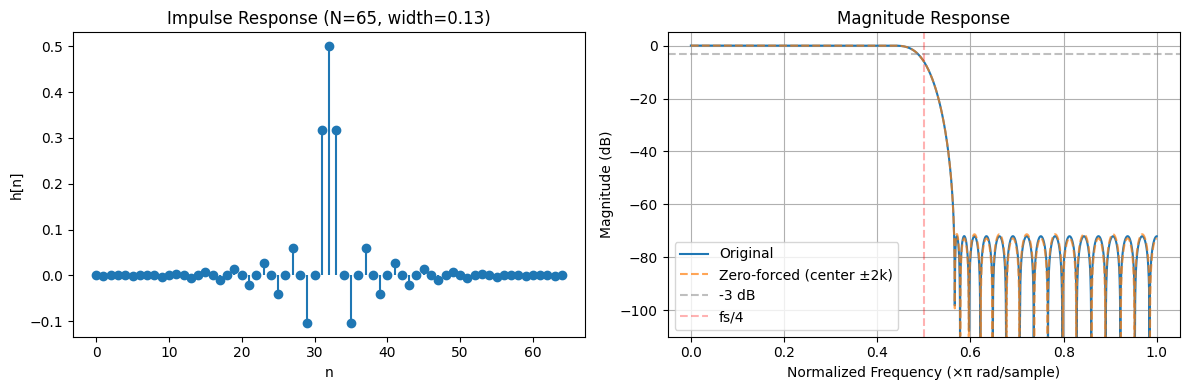

// kHalfbandCoeffs (N=65)
static constexpr std::array<float, 65> kHalfbandCoeffs = {
    -0.0000003856f,
    -0.0003044707f,
    0.0000010085f,
    0.0005326581f,
    -0.0000017348f,
    -0.0009739876f,
    0.0000027020f,
    0.0016310629f,
    -0.0000039780f,
    -0.0025679886f,
    0.0000054613f,
    0.0038614894f,
    -0.0000072091f,
    -0.0056054843f,
    0.0000090709f,
    0.0079210177f,
    -0.0000111919f,
    -0.0109748173f,
    0.0000132931f,
    0.0150179768f,
    -0.0000152761f,
    -0.0204685818f,
    0.0000171944f,
    0.0281074181f,
    -0.0000190393f,
    -0.0396091882f,
    0.0000203860f,
    0.0593530469f,
    -0.0000213413f,
    -0.1034683564f,
    0.0000220592f,
    0.3174232112f,
    0.4999779612f,
    0.3174232112f,
    0.0000220592f,
    -0.1034683564f,
    -0.0000213413f,
    0.0593530469f,
    0.0000203860f,
    -0.0396091882f,
    -0.0000190393f,
    0.0281074181f,
    0.0000171944f,
    -0.0204685818f,
    -0.0000152761f,
    0.0150179768f,
    0.0000132931f,


In [71]:
coeffs_rem = design_halfband(order=64, width=0.13)
export_cpp_array(coeffs_rem)

In [ ]:
def design_polyphase_remez(taps, width, ratio):
    """Design a polyphase resampling filter via remez.

    Parameters
    ----------
    taps : int
        Number of taps.
    width : float
        Normalized transition bandwidth.
    ratio : float
        Resampling ratio R → cutoff = π / R (normalized: 1.0 / ratio).

    Returns
    -------
    coeffs : ndarray
        Filter coefficients.
    """
    cutoff = 1.0 / ratio
    fp = cutoff - width / 2
    fs = cutoff + width / 2
    # fp = cutoff - width
    # fs = cutoff

    bands = [0.0, fp, fs, 1.0]
    desired = [1.0, 0.0]
    weight = [1.0, 1.0]

    coeffs = signal.remez(taps, bands, desired, weight=weight, fs=2.0)

    # Frequency response
    w, h = signal.freqz(coeffs, worN=4096)
    mag_db = 20 * np.log10(np.maximum(np.abs(h), 1e-12))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.stem(coeffs, basefmt=" ")
    ax1.set_title(f"Impulse Response (taps={taps}, width={width}, R={ratio})")
    ax1.set_xlabel("n")
    ax1.set_ylabel("h[n]")

    ax2.plot(w / np.pi, mag_db)
    ax2.axvline(
        cutoff, color="red", linestyle="--", alpha=0.3, label=f"cutoff = π/{ratio:.0f}"
    )
    ax2.set_title("Magnitude Response")
    ax2.set_xlabel("Normalized Frequency (×π rad/sample)")
    ax2.set_ylabel("Magnitude (dB)")
    ax2.set_ylim(-110, 5)
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

    return coeffs

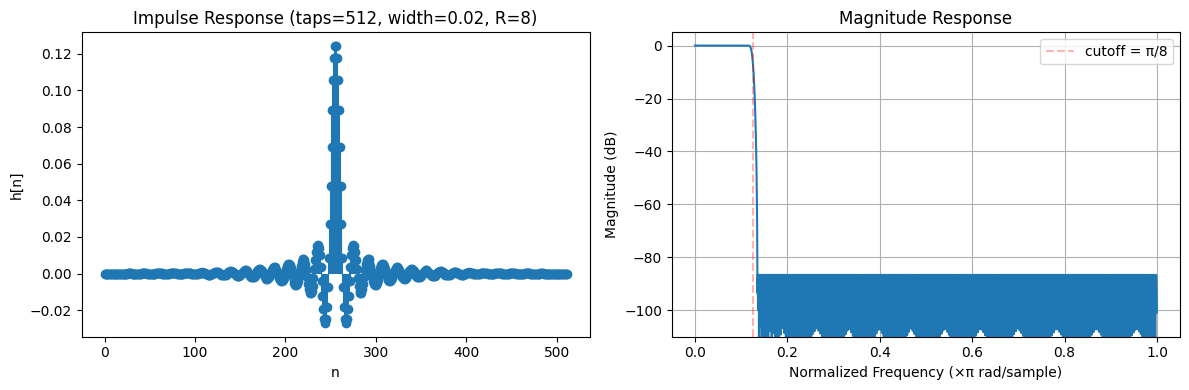

// kPolyphaseCoeffs (N=512)
static constexpr std::array<float, 512> kPolyphaseCoeffs = {
    0.0000148924f,
    -0.0000149728f,
    -0.0000122360f,
    -0.0000111857f,
    -0.0000103326f,
    -0.0000087969f,
    -0.0000061759f,
    -0.0000024478f,
    0.0000020667f,
    0.0000067966f,
    0.0000110008f,
    0.0000139155f,
    0.0000148724f,
    0.0000134568f,
    0.0000095923f,
    0.0000036227f,
    -0.0000037181f,
    -0.0000113583f,
    -0.0000180587f,
    -0.0000225736f,
    -0.0000238986f,
    -0.0000214247f,
    -0.0000151554f,
    -0.0000056478f,
    0.0000057880f,
    0.0000175926f,
    0.0000277610f,
    0.0000344565f,
    0.0000362615f,
    0.0000323404f,
    0.0000227281f,
    0.0000084347f,
    -0.0000086481f,
    -0.0000259991f,
    -0.0000408155f,
    -0.0000504395f,
    -0.0000528082f,
    -0.0000468521f,
    -0.0000327673f,
    -0.0000120976f,
    0.0000123969f,
    0.0000370850f,
    0.0000579833f,
    0.0000713735f,
    0.0000744409f,
    0.0000657952f,
    0.00004585

In [ ]:
# ---- usage ----
coeffs_poly = design_polyphase_remez(taps=64 * 8, width=0.02, ratio=8)
export_cpp_array(coeffs_poly, name="kPolyphaseCoeffs")